## Startup


80/20 rule:
80% calibration (2000-2020)
20% validation (2020-2025)

In [2]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

from ipywidgets import IntProgress
from IPython.display import display

In [3]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

### Defining variables & pathways

In [4]:
# Naming region 

hysets_id = "hysets_07DA001"
basin_size = 132572

In [5]:
# Choosing time period

experiment_start_date = "2000-01-01T00:00:00Z"
experiment_end_date = "2005-12-31T00:00:00Z"

In [6]:
# Create pathways for ERA 5 forcings

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "Workyard" / "forcing_trial" / hysets_id / "ERA5"
forcing_path_ERA5.mkdir(exist_ok=True, parents=True)

discharge_file = Path.home() / "BEP-maxime" / "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

calibration_temp = Path.home() / "BEP-maxime" / "Workyard" / "calibration_temp"
calibration_temp.mkdir(parents=True, exist_ok=True)

### Load & prepare discharge data 

In [7]:
# Load CSV discharge 07DA001

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

In [8]:
# Filter q_obs to start & end date

start_date = pd.to_datetime(experiment_start_date.replace("Z", ""))
end_date = pd.to_datetime(experiment_end_date.replace("Z", ""))

q_obs = q_obs[(q_obs["Date"] >= start_date) & (q_obs["Date"] <= end_date)].copy()

observed_output = pd.Series(data=q_obs["discharge_m3s"].to_numpy(), name="Observed discharge", index=q_obs["Date"])

### Generate ERA5 data

In [1]:
# Generate ERA5 data

ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
    dataset="ERA5",
    start_time=experiment_start_date,
    end_time=experiment_end_date,
    shape=shape_file,
)

NameError: name 'ewatercycle' is not defined

## Calibration Methods

### Method 1: RMSE

In [51]:
def RMSE(sim, obs):
    sim = sim.to_numpy()
    obs = obs.to_numpy()

    return np.sqrt(np.mean((obs - sim)) ** 2)

### Method 2: NSE

In [47]:
def NSE(sim, obs):
    sim = sim.to_numpy()
    obs = obs.to_numpy()

    return 1 - np.sum((obs - sim) ** 2) / np.sum((obs - np.mean(obs)) ** 2)

### Method 3: Log_NSE

In [20]:
def log_NSE(sim, obs):
    sim = sim.to_numpy()
    obs = obs.to_numpy()

    # Avoid log(0)
    eps = 0.00000000001

    log_sim = np.log(sim + eps)
    log_obs = np.log(obs + eps)

    return 1 - np.sum((log_obs - log_sim) ** 2) / np.sum((log_obs - np.mean(log_obs)) ** 2)

## Calibration start

In [21]:
# Create function to run the model

def run_hbv(parameters, initial_storages, forcing):

    # Create model object
    model = ewatercycle.models.HBV(forcing=forcing)

    # Create config file
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storages=initial_storages,
        cfg_dir=calibration_temp
    )

    # Initialising model
    model.initialize(config_file)

    # Define & update outputs 
    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Convert mm/day to m3/s
    model_output_mmday = pd.Series(
        data=Q_m, 
        index=time, 
        name="Modelled discharge"
    )
    model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

    return model_output_m3s

### Define Parameters & Storages

In [54]:
# Define initial storages
#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

# # Define parameters
# par_names = ["Imax",
#                "Ce",
#                "Sumax",
#                "Beta",
#                "Pmax",
#                "Tlag",
#                "Kf",
#                "Ks",
#                "FM"
#                ]
# p_min = np.array([0,   0.1,  10,  0.1, 0.001, 0,   0.001, 0.0001, 0.01])
# p_max = np.array([10,  2.0, 500,  5.0, 0.3,   10,  0.1,   0.01,   0.5])

# Define parameters
parameter_ranges = {
    "Imax":  (2.5, 8.5),            # Maximum interception storage
    "Ce":    (0.38, 0.5),       # Evaporation correction factor
    "Sumax": (140, 275),         # Maximum soil moisture storage
    "Beta":  (1.5, 2.3),          # Soil runoff parameter
    "Pmax":  (0.2, 1.4),            # Maximum percolation rate
    "Tlag":  (5.8, 8.7),           # Time lag
    "Kf":    (0.02, 0.35),       # Fast reservoir recession coefficient
    "Ks":    (0.001, 0.1),     # Slow reservoir recession coefficient
    "FM":    (0.35, 1),          # Snowmelt factor
}

# parameter_ranges = {
#     "Imax":  (3, 8.5),
#     "Ce":    (0.35, 0.48),
#     "Sumax": (140, 280),
#     "Beta":  (1.5, 2.2),
#     "Pmax":  (0.15, 1.2),
#     "Tlag":  (6, 9),
#     "Kf":    (0.04, 0.30),
#     "Ks":    (0.025, 0.07),
#     "FM":    (0.35, 1.1),
# }

# Convert to arrays
parameter_names = list(parameter_ranges.keys())

p_min = np.array([parameter_ranges[name][0] for name in parameter_names])
p_max = np.array([parameter_ranges[name][1] for name in parameter_names])

# Create samples
N = 300
par_samples = np.random.rand(N, len(parameter_ranges))                  # Generates values between 0-1
parameter_sets = p_min + par_samples * (p_max - p_min)                  # Fits value to parameter range

print(parameter_sets[:][0])

[7.04132074e+00 3.86890731e-01 2.00329377e+02 1.57156950e+00
 2.93221286e-01 8.51057360e+00 3.11747433e-01 2.11115492e-02
 9.50756202e-01]

## LoopdiLoop

In [55]:
results = []

# Progress bar for visualization
f = IntProgress(min=0, max=N)
display(f)

for i in range(N):
    print(f"Running parameter set {i+1}/{N}")

    simulated = run_hbv(
        parameters=parameter_sets[i], 
        initial_storages=s_0, 
        forcing=ERA5_forcing
    )

    # Filter data by day only, not by day & time to prevent alignment issues
    simulated_daily = simulated
    observed_daily = observed_output

    simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
    observed_daily.index = pd.to_datetime(observed_daily.index).tz_localize(None).normalize()
    
    # Align simulated and observed data
    combined_data = pd.DataFrame(
        {"Modelled discharge": simulated_daily, 
        "Observed discharge": observed_daily}
    ).dropna()

    # Skip first year as warm-up
    combined_data = combined_data[combined_data.index >= "2001-01-01"]
    
    # Append results
    if combined_data.empty:
        print(f"No overlapping data for parameter set {i+1}")
        nse = np.nan
        log_nse = np.nan
    else:
        nse = NSE(
            combined_data["Modelled discharge"], 
            combined_data["Observed discharge"]
        )
        log_nse = log_NSE(
            combined_data["Modelled discharge"], 
            combined_data["Observed discharge"]
        )
        
    results.append({
        "run": i,
        "NSE": nse,
        "log_NSE": log_nse,
        "parameters": parameter_sets[i]
    })

IntProgress(value=0, max=300)

Running parameter set 1/300

Running parameter set 2/300

Running parameter set 3/300

Running parameter set 4/300

...

Running parameter set 296/300

Running parameter set 297/300

Running parameter set 298/300

Running parameter set 299/300

Running parameter set 300/300

### Display results

In [56]:
results = pd.DataFrame(results)

print(results[["run", "NSE", "log_NSE"]])

# Best NSE
best_run_nse = results["NSE"].idxmax()
best_result_nse = results.loc[best_run_nse]

best_parameters_nse = best_result_nse["parameters"]
best_nse = best_result_nse["NSE"]

print(f'Best run: {best_run_nse} with NSE: {best_nse}, with parameters:')
print(list(zip(parameter_names, best_parameters_nse)))

# Best log_NSE
best_run_log_nse = results["log_NSE"].idxmax()
best_result_log_nse = results.loc[best_run_log_nse]

best_parameters_log_nse = best_result_log_nse["parameters"]
best_log_nse = best_result_log_nse["log_NSE"]

print(f'Best run: {best_run_log_nse} with log_NSE: {best_log_nse}, with parameters:')
print(list(zip(parameter_names, best_parameters_log_nse)))

run       NSE   log_NSE
0      0  0.439754  0.709099
1      1  0.699835  0.776052
2      2  0.782790  0.795898
3      3  0.408743  0.376669
4      4  0.382206  0.721494
..   ...       ...       ...
295  295  0.705821  0.809451
296  296  0.666569  0.698280
297  297  0.481626  0.689337
298  298  0.472785  0.363001
299  299  0.230548  0.231731

[300 rows x 3 columns]

Best run: 179 with NSE: 0.8095358934408565, with parameters:

[
    ('Imax', 6.279135309789487),
    ('Ce', 0.48082432749007864),
    ('Sumax', 174.127749336179),
    ('Beta', 1.9527195686909842),
    ('Pmax', 0.3305087197271726),
    ('Tlag', 6.199192091400492),
    ('Kf', 0.07683628832422615),
    ('Ks', 0.004363984839521473),
    ('FM', 0.40766060413663546)
]

Best run: 179 with log_NSE: 0.8717169479201906, with parameters:

[
    ('Imax', 6.279135309789487),
    ('Ce', 0.48082432749007864),
    ('Sumax', 174.127749336179),
    ('Beta', 1.9527195686909842),
    ('Pmax', 0.3305087197271726),
    ('Tlag', 6.199192091400492),
    ('Kf', 0.07683628832422615),
    ('Ks', 0.004363984839521473),
    ('FM', 0.40766060413663546)
]

In [62]:
# Manual check for other runs

selected_run = results.loc[295]
print(list(zip(parameter_names, selected_run["parameters"])))

[
    ('Imax', 6.2391126094287115),
    ('Ce', 0.4059034482695777),
    ('Sumax', 154.67204503110761),
    ('Beta', 1.754032781455765),
    ('Pmax', 0.39617478157458713),
    ('Tlag', 8.374403905226643),
    ('Kf', 0.1561690712250938),
    ('Ks', 0.01336758499776439),
    ('FM', 0.4720208296914324)
]

In [57]:
# Calculate RMSE for best parameter sets NSE and log_NSE

rmse_nse = RMSE(
    plot_data["Modelled discharge NSE"],
    plot_data["Observed discharge"]
)

rmse_log_nse = RMSE(
    plot_data["Modelled discharge log_NSE"],
    plot_data["Observed discharge"]
)

print(f"RMSE for best NSE parameter set: {rmse_nse:.3f} m³/s")
print(f"RMSE for best log_NSE parameter set: {rmse_log_nse:.3f} m³/s")

RMSE for best NSE parameter set: 52.624 m³/s

RMSE for best log_NSE parameter set: 62.495 m³/s

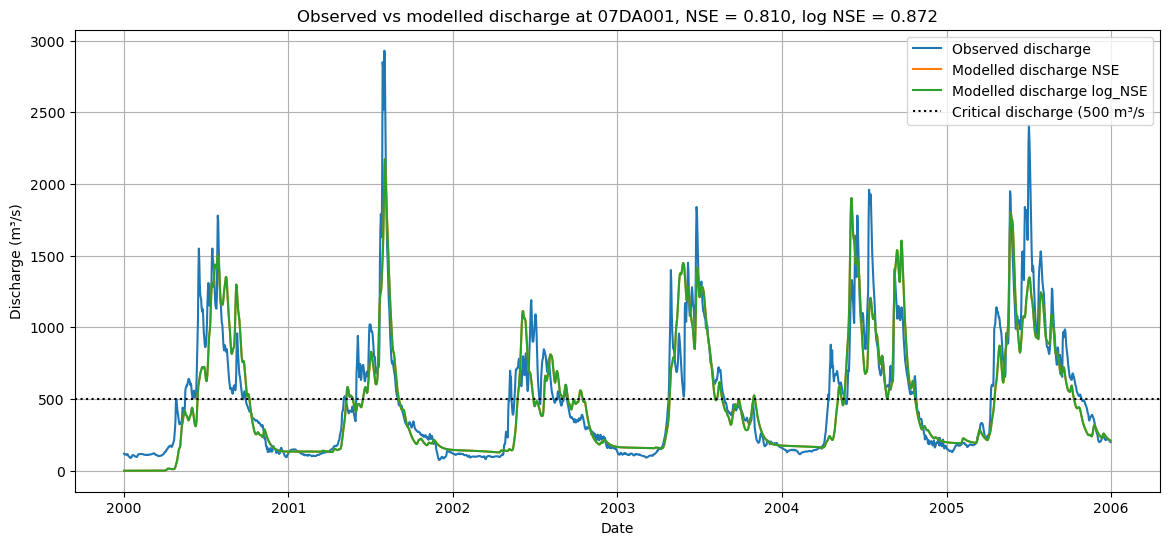

In [58]:
# Plot

q_critical = 500

simulated_calibrated_nse = run_hbv(
    parameters=best_parameters_nse,
    initial_storages=s_0,
    forcing=ERA5_forcing
)

simulated_calibrated_log_nse = run_hbv(
    parameters=best_parameters_log_nse,
    initial_storages=s_0,
    forcing=ERA5_forcing
)

# Align dates
simulated_plot_nse = simulated_calibrated_nse
simulated_plot_log_nse = simulated_calibrated_log_nse
observed_plot = observed_output

simulated_plot_nse.index = pd.to_datetime(simulated_plot_nse.index).tz_localize(None).normalize()
simulated_plot_log_nse.index = pd.to_datetime(simulated_plot_log_nse.index).tz_localize(None).normalize()
observed_plot.index = pd.to_datetime(observed_plot.index).tz_localize(None).normalize()

# Combine modelled and observed data
plot_data = pd.DataFrame({
    "Modelled discharge NSE": simulated_plot_nse,
    "Modelled discharge log_NSE": simulated_plot_log_nse,
    "Observed discharge": observed_plot
}).dropna()

# Calculate NSE for plotted data
plot_nse = NSE(
    plot_data["Modelled discharge NSE"],
    plot_data["Observed discharge"]
)

plot_log_nse = log_NSE(
    plot_data["Modelled discharge log_NSE"],
    plot_data["Observed discharge"]
)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(plot_data.index, plot_data["Observed discharge"], label="Observed discharge")
plt.plot(plot_data.index, plot_data["Modelled discharge NSE"], label="Modelled discharge NSE")
plt.plot(plot_data.index, plot_data["Modelled discharge log_NSE"], label="Modelled discharge log_NSE")

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title(f"Observed vs modelled discharge at 07DA001, NSE = {best_nse:.3f}, log NSE = {best_log_nse:.3f}")
plt.axhline(y=q_critical, linestyle=":", label=f'Critical discharge ({q_critical} m³/s', color='black')
plt.legend()
plt.grid(True)
plt.show()